In [2]:
import pandas as pd

trips_by_distance = pd.read_csv('Trips_by_Distance.csv')
trips_full_data = pd.read_csv('Trips_Full_Data.csv')

In [3]:
print(trips_by_distance.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500866 entries, 0 to 500865
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Level                           500866 non-null  object 
 1   Date                            500866 non-null  object 
 2   State FIPS                      499965 non-null  float64
 3   State Postal Code               499965 non-null  object 
 4   County FIPS                     454014 non-null  float64
 5   County Name                     454014 non-null  object 
 6   Population Staying at Home      497857 non-null  float64
 7   Population Not Staying at Home  497857 non-null  float64
 8   Number of Trips                 497857 non-null  float64
 9   Number of Trips <1              497857 non-null  float64
 10  Number of Trips 1-3             497857 non-null  float64
 11  Number of Trips 3-5             497857 non-null  float64
 12  Number of Trips 

In [4]:
print(trips_by_distance.describe())

          State FIPS    County FIPS  Population Staying at Home  \
count  499965.000000  454014.000000                4.978570e+05   
mean       30.112156   30332.235358                2.823561e+05   
std        15.200125   15164.296350                3.203914e+06   
min         1.000000    1001.000000                1.200000e+01   
25%        18.000000   18171.000000                2.113000e+03   
50%        29.000000   29165.000000                5.450000e+03   
75%        45.000000   45075.000000                2.122100e+04   
max        56.000000   56045.000000                1.102118e+08   

       Population Not Staying at Home  Number of Trips  Number of Trips <1  \
count                    4.978570e+05     4.978570e+05        4.978570e+05   
mean                     9.960810e+05     4.654529e+06        1.156359e+06   
std                      1.101019e+07     5.207341e+07        1.295770e+07   
min                      1.120000e+02     3.890000e+02        0.000000e+00   
25%   

In [5]:
trips_by_distance['Date'] = pd.to_datetime(trips_by_distance['Date'])

In [6]:
print(trips_by_distance.isnull().sum())

trips_by_distance = trips_by_distance.fillna(trips_by_distance.mean(numeric_only=True))

Level                                 0
Date                                  0
State FIPS                          901
State Postal Code                   901
County FIPS                       46852
County Name                       46852
Population Staying at Home         3009
Population Not Staying at Home     3009
Number of Trips                    3009
Number of Trips <1                 3009
Number of Trips 1-3                3009
Number of Trips 3-5                3009
Number of Trips 5-10               3009
Number of Trips 10-25              3009
Number of Trips 25-50              3009
Number of Trips 50-100             3009
Number of Trips 100-250            3009
Number of Trips 250-500            3009
Number of Trips >=500              3009
Row ID                                1
Week                                  1
Month                                 1
dtype: int64


In [7]:
X = trips_by_distance[['Number of Trips 1-3']]
y = trips_by_distance['Number of Trips 5-10']


In [8]:
print("Independent Variable (X):")
display(X.head())

print("Dependent Variable (y):")
display(y.head())

Independent Variable (X):


,Number of Trips 1-3
0,234284795.0
1,285887315.0
2,290074425.0
3,295643296.0
4,304168709.0


Dependent Variable (y):


,Number of Trips 5-10
0,129670778.0
1,171637514.0
2,175775410.0
3,181324645.0
4,180941769.0


In [9]:
print(trips_by_distance.isnull().sum())

Level                                 0
Date                                  0
State FIPS                            0
State Postal Code                   901
County FIPS                           0
County Name                       46852
Population Staying at Home            0
Population Not Staying at Home        0
Number of Trips                       0
Number of Trips <1                    0
Number of Trips 1-3                   0
Number of Trips 3-5                   0
Number of Trips 5-10                  0
Number of Trips 10-25                 0
Number of Trips 25-50                 0
Number of Trips 50-100                0
Number of Trips 100-250               0
Number of Trips 250-500               0
Number of Trips >=500                 0
Row ID                                1
Week                                  0
Month                                 0
dtype: int64


In [10]:
print(trips_by_distance.duplicated().sum())

0


In [11]:
trips_by_distance = trips_by_distance.drop_duplicates()

In [12]:
trips_by_distance = trips_by_distance[trips_by_distance['Level'] == 'National']

print(trips_by_distance['Level'].unique())
print(trips_by_distance.shape)

['National']
(901, 22)


In [13]:
print(trips_by_distance[['Number of Trips 10-25', 'Number of Trips 50-100']].head())

   Number of Trips 10-25  Number of Trips 50-100
0            116904343.0              15686639.0
1            167412698.0              17739183.0
2            172027487.0              18366626.0
3            176144493.0              19315785.0
4            165239790.0              19363939.0


In [14]:
set1 = trips_by_distance[trips_by_distance['Number of Trips 10-25'] > 10000000]
set2 = trips_by_distance[trips_by_distance['Number of Trips 50-100'] > 10000000]

print("Set1 size:", set1.shape)
print("Set2 size:", set2.shape)

Set1 size: (901, 22)
Set2 size: (900, 22)


In [15]:
weekly_data = trips_by_distance.groupby('Week').mean(numeric_only=True)

print(weekly_data.head())

      State FIPS   County FIPS  Population Staying at Home  \
Week                                                         
0.0    30.112156  30332.235358                7.384405e+07   
1.0    30.112156  30332.235358                7.222715e+07   
2.0    30.112156  30332.235358                7.144295e+07   
3.0    30.112156  30332.235358                6.998493e+07   
4.0    30.112156  30332.235358                6.982941e+07   

      Population Not Staying at Home  Number of Trips  Number of Trips <1  \
Week                                                                        
0.0                     2.528688e+08     1.066557e+09        2.673173e+08   
1.0                     2.546069e+08     1.092055e+09        2.757515e+08   
2.0                     2.553911e+08     1.109787e+09        2.832839e+08   
3.0                     2.568492e+08     1.119638e+09        2.856147e+08   
4.0                     2.570047e+08     1.113146e+09        2.855405e+08   

      Number of Trips 1-3

In [40]:
import time

start = time.time()

df = pd.read_csv('Trips_by_Distance.csv')
df_mean = df['Number of Trips'].mean()

end = time.time()
print("Pandas Time:", end - start)

Pandas Time: 21.28803777694702


In [17]:
# Install dask[distributed] to resolve the ImportError
!pip install dask[distributed]

from dask.distributed import Client
import time
import dask.dataframe as dd

client = Client(n_workers=10)

start = time.time()

dtypes_dict = {'County Name': 'object',
       'Number of Trips': 'float64',
       'Number of Trips 1-3': 'float64',
       'Number of Trips 10-25': 'float64',
       'Number of Trips 100-250': 'float64',
       'Number of Trips 25-50': 'float64',
       'Number of Trips 250-500': 'float64',
       'Number of Trips 3-5': 'float64',
       'Number of Trips 5-10': 'float64',
       'Number of Trips 50-100': 'float64',
       'Number of Trips <1': 'float64',
       'Number of Trips >=500': 'float64',
       'Population Not Staying at Home': 'float64',
       'Population Staying at Home': 'float64',
       'State Postal Code': 'object'}
ddf = dd.read_csv('Trips_by_Distance.csv', dtype=dtypes_dict)
ddf_mean = ddf['Number of Trips'].mean().compute()

end = time.time()
print("Dask Time (10 workers):", end - start)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.1 MB/s eta 0:00:00


INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:43523
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:42171'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36863'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43313'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38315'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:39021'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40863'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40961'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33153'
INFO:distributed.nanny:        Start Na

Dask Time (10 workers): 10.92934536933899


In [42]:
# Install dask[distributed] to resolve the ImportError
!pip install dask[distributed]

from dask.distributed import Client
import time
import dask.dataframe as dd

# Close any existing Dask client to prevent conflicts
try:
    client.close()
except: # noqa: E722
    pass

# Reduce the number of workers to avoid memory issues
client = Client(n_workers=10)

start = time.time()

dtypes_dict = {'County Name': 'object',
       'Number of Trips': 'float64',
       'Number of Trips 1-3': 'float64',
       'Number of Trips 10-25': 'float64',
       'Number of Trips 100-250': 'float64',
       'Number of Trips 25-50': 'float64',
       'Number of Trips 250-500': 'float64',
       'Number of Trips 3-5': 'float64',
       'Number of Trips 5-10': 'float64',
       'Number of Trips 50-100': 'float64',
       'Number of Trips <1': 'float64',
       'Number of Trips >=500': 'float64',
       'Population Not Staying at Home': 'float64',
       'Population Staying at Home': 'float64',
       'State Postal Code': 'object',
       'Week': 'float64',
       'Month': 'float64'}
ddf = dd.read_csv('Trips_by_Distance.csv', dtype=dtypes_dict)
ddf_mean = ddf['Number of Trips'].mean().compute()

end = time.time()
print("Dask Time (10 workers):", end - start)

INFO:distributed.core:Event loop was unresponsive in Nanny for 4.11s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 4.21s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 4.25s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 4.57s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 4.69s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts an

Dask Time (10 workers): 47.7625675201416


In [19]:
national_only = trips_by_distance[trips_by_distance['Level'] == 'National']

start_date = trips_full_data['Date'].min()
end_date = trips_full_data['Date'].max()

small_set = national_only[national_only['Date'].between(start_date, end_date)]


In [20]:
weekly_home = small_set.groupby('Week')['Population Staying at Home'].mean()
weekly_not_home = small_set.groupby('Week')['Population Not Staying at Home'].mean()


In [21]:
set1 = national_only[national_only['Number of Trips 10-25'] > 10000000]
set2 = national_only[national_only['Number of Trips 50-100'] > 10000000]


In [22]:
X = national_only[['Number of Trips 1-3']]
y = national_only['Number of Trips 5-10']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [26]:
y_pred = model.predict(X_test)

In [25]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)


Coefficient: [0.65340388]
Intercept: -9567827.440689772


In [27]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)


LinearRegression()

In [28]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 9161393.2399746
R²: 0.9341234186671288


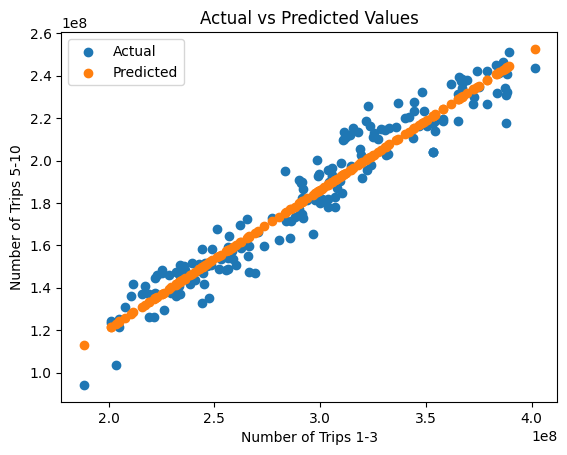

In [34]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")
plt.xlabel("Number of Trips 1-3")
plt.ylabel("Number of Trips 5-10")
plt.legend()
plt.title("Actual vs Predicted Values")
plt.show()


In [29]:
selected_cols = [
    'Population Staying at Home',
    'Population Not Staying at Home',
    'Number of Trips',
    'Number of Trips 1-3',
    'Number of Trips 5-10',
    'Number of Trips 10-25',
    'Number of Trips 50-100'
]

print(trips_by_distance[selected_cols].describe())


       Population Staying at Home  Population Not Staying at Home  \
count                9.010000e+02                    9.010000e+02   
mean                 7.293896e+07                    2.539483e+08   
std                  1.163743e+07                    1.133039e+07   
min                  5.242747e+07                    2.169556e+08   
25%                  6.278892e+07                    2.454691e+08   
50%                  7.033044e+07                    2.567529e+08   
75%                  8.162207e+07                    2.635359e+08   
max                  1.102118e+08                    2.737400e+08   

       Number of Trips  Number of Trips 1-3  Number of Trips 5-10  \
count     9.010000e+02         9.010000e+02          9.010000e+02   
mean      1.184806e+09         2.951012e+08          1.832435e+08   
std       2.084187e+08         5.360508e+07          3.630781e+07   
min       5.242390e+08         1.291684e+08          8.312420e+07   
25%       9.925871e+08         2.

In [30]:
selected_cols = [
    'Population Staying at Home',
    'Population Not Staying at Home',
    'Number of Trips',
    'Number of Trips 1-3',
    'Number of Trips 5-10',
    'Number of Trips 10-25',
    'Number of Trips 50-100'
]

print(trips_by_distance[selected_cols].median())
print(trips_by_distance[selected_cols].var())

Population Staying at Home        7.033044e+07
Population Not Staying at Home    2.567529e+08
Number of Trips                   1.189940e+09
Number of Trips 1-3               2.959082e+08
Number of Trips 5-10              1.817567e+08
Number of Trips 10-25             1.764698e+08
Number of Trips 50-100            1.896169e+07
dtype: float64
Population Staying at Home        1.354299e+14
Population Not Staying at Home    1.283777e+14
Number of Trips                   4.343836e+16
Number of Trips 1-3               2.873504e+15
Number of Trips 5-10              1.318257e+15
Number of Trips 10-25             1.458236e+15
Number of Trips 50-100            6.444585e+12
dtype: float64


In [31]:
weekly_analysis = trips_by_distance.groupby('Week')[[
    'Population Staying at Home',
    'Population Not Staying at Home',
    'Number of Trips 10-25',
    'Number of Trips 50-100'
]].mean()

print(weekly_analysis.head())


      Population Staying at Home  Population Not Staying at Home  \
Week                                                               
0.0                 7.384405e+07                    2.528688e+08   
1.0                 7.222715e+07                    2.546069e+08   
2.0                 7.144295e+07                    2.553911e+08   
3.0                 6.998493e+07                    2.568492e+08   
4.0                 6.982941e+07                    2.570047e+08   

      Number of Trips 10-25  Number of Trips 50-100  
Week                                                 
0.0            1.547072e+08            1.794145e+07  
1.0            1.589211e+08            1.690457e+07  
2.0            1.603820e+08            1.696067e+07  
3.0            1.636404e+08            1.765393e+07  
4.0            1.617752e+08            1.718349e+07  


In [32]:
correlation_matrix = trips_by_distance[selected_cols].corr()
print(correlation_matrix)


                                Population Staying at Home  \
Population Staying at Home                        1.000000   
Population Not Staying at Home                   -0.998609   
Number of Trips                                  -0.820275   
Number of Trips 1-3                              -0.796139   
Number of Trips 5-10                             -0.806275   
Number of Trips 10-25                            -0.799407   
Number of Trips 50-100                           -0.069283   

                                Population Not Staying at Home  \
Population Staying at Home                           -0.998609   
Population Not Staying at Home                        1.000000   
Number of Trips                                       0.820316   
Number of Trips 1-3                                   0.790209   
Number of Trips 5-10                                  0.803700   
Number of Trips 10-25                                 0.792711   
Number of Trips 50-100                   

In [33]:
set1 = trips_by_distance[trips_by_distance['Number of Trips 10-25'] > 10000000]
set2 = trips_by_distance[trips_by_distance['Number of Trips 50-100'] > 10000000]

print("10-25 over 10,000,000:", set1.shape[0])
print("50-100 over 10,000,000:", set2.shape[0])


10-25 over 10,000,000: 901
50-100 over 10,000,000: 900


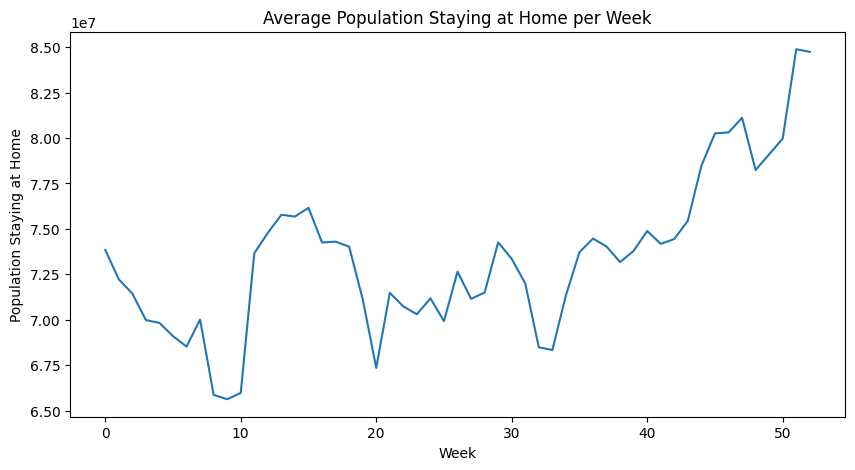

In [36]:
import matplotlib.pyplot as plt

weekly_home = trips_by_distance.groupby('Week')['Population Staying at Home'].mean()

plt.figure(figsize=(10, 5))
plt.plot(weekly_home.index, weekly_home.values)
plt.xlabel('Week')
plt.ylabel('Population Staying at Home')
plt.title('Average Population Staying at Home per Week')
plt.show()

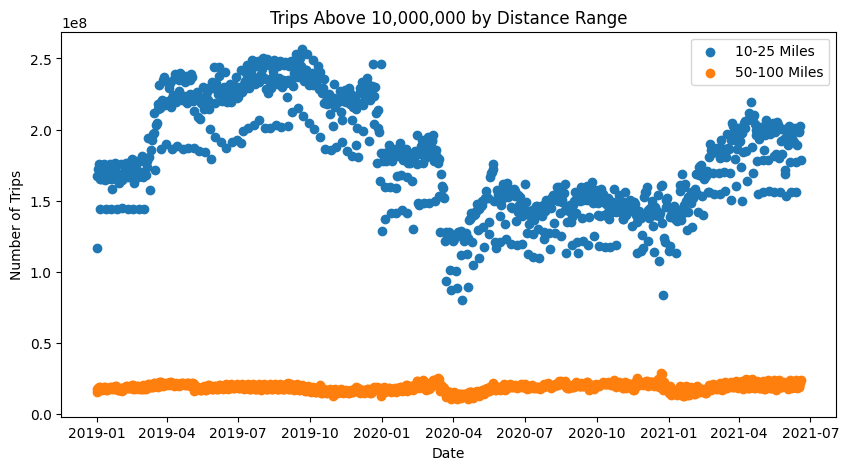

In [37]:
set1 = trips_by_distance[trips_by_distance['Number of Trips 10-25'] > 10000000]
set2 = trips_by_distance[trips_by_distance['Number of Trips 50-100'] > 10000000]

plt.figure(figsize=(10, 5))
plt.scatter(set1['Date'], set1['Number of Trips 10-25'], label='10-25 Miles')
plt.scatter(set2['Date'], set2['Number of Trips 50-100'], label='50-100 Miles')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.title('Trips Above 10,000,000 by Distance Range')
plt.legend()
plt.show()


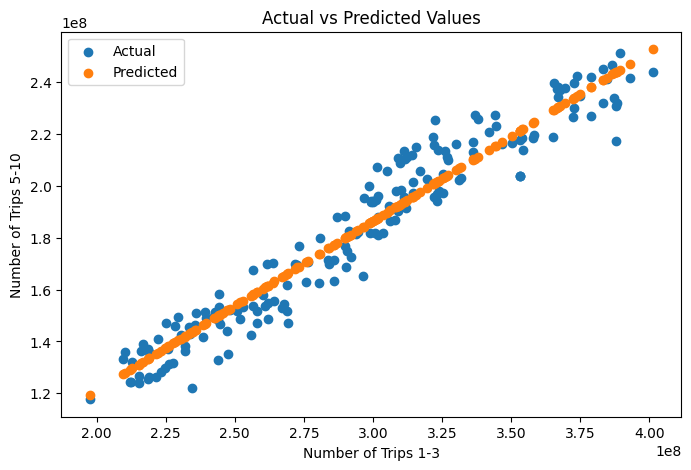

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, label='Actual')
plt.scatter(X_test, y_pred, label='Predicted')
plt.xlabel('Number of Trips 1-3')
plt.ylabel('Number of Trips 5-10')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()


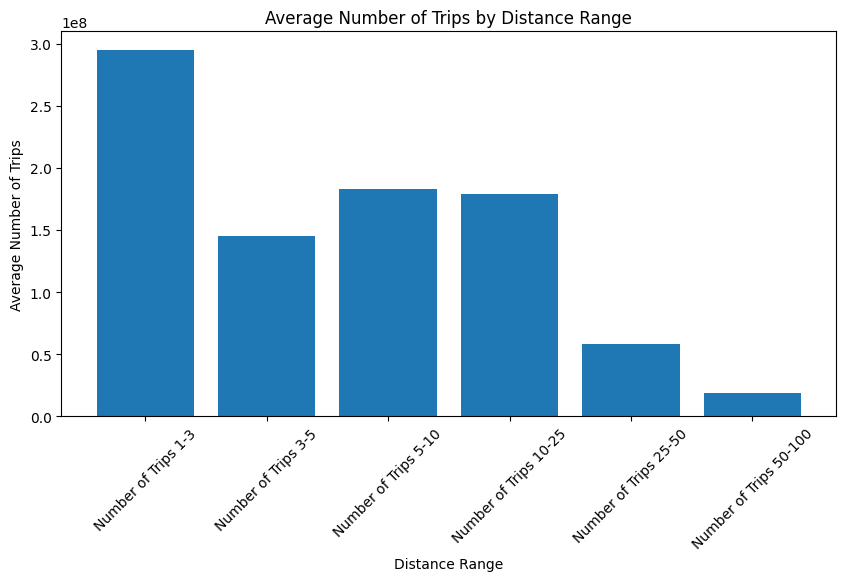

In [43]:
distance_means = trips_by_distance[[
    'Number of Trips 1-3',
    'Number of Trips 3-5',
    'Number of Trips 5-10',
    'Number of Trips 10-25',
    'Number of Trips 25-50',
    'Number of Trips 50-100'
]].mean()

plt.figure(figsize=(10, 5))
plt.bar(distance_means.index, distance_means.values)
plt.xticks(rotation=45)
plt.xlabel('Distance Range')
plt.ylabel('Average Number of Trips')
plt.title('Average Number of Trips by Distance Range')
plt.show()


In [ ]:
weekly_home = trips_by_distance.groupby('Week')['Population Staying at Home'].mean()
weekly_not_home = trips_by_distance.groupby('Week')['Population Not Staying at Home'].mean()

print(weekly_home.head())
print(weekly_not_home.head())


Week
0    7.384405e+07
1    7.222715e+07
2    7.144295e+07
3    6.998493e+07
4    6.982941e+07
Name: Population Staying at Home, dtype: float64
Week
0    2.528688e+08
1    2.546069e+08
2    2.553911e+08
3    2.568492e+08
4    2.570047e+08
Name: Population Not Staying at Home, dtype: float64


In [ ]:
distance_cols = [
    'Number of Trips 1-3',
    'Number of Trips 3-5',
    'Number of Trips 5-10',
    'Number of Trips 10-25',
    'Number of Trips 25-50',
    'Number of Trips 50-100'
]

distance_means = trips_by_distance[distance_cols].mean()
print(distance_means)


Number of Trips 1-3       2.951012e+08
Number of Trips 3-5       1.451094e+08
Number of Trips 5-10      1.832435e+08
Number of Trips 10-25     1.790053e+08
Number of Trips 25-50     5.794898e+07
Number of Trips 50-100    1.897604e+07
dtype: float64


In [ ]:
set1 = trips_by_distance[trips_by_distance['Number of Trips 10-25'] > 10000000]
set2 = trips_by_distance[trips_by_distance['Number of Trips 50-100'] > 10000000]

print(set1[['Date', 'Number of Trips 10-25']].head())
print(set2[['Date', 'Number of Trips 50-100']].head())


        Date  Number of Trips 10-25
0 2019-01-01            116904343.0
1 2019-01-02            167412698.0
2 2019-01-03            172027487.0
3 2019-01-04            176144493.0
4 2019-01-05            165239790.0
        Date  Number of Trips 50-100
0 2019-01-01              15686639.0
1 2019-01-02              17739183.0
2 2019-01-03              18366626.0
3 2019-01-04              19315785.0
4 2019-01-05              19363939.0


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 9161393.2399746
R²: 0.9341234186671288
